# **Init setting**

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"   # 충돌 허용
os.environ["OMP_NUM_THREADS"] = "1"            # OpenMP 병렬 스레드 최소화
os.environ["MKL_NUM_THREADS"] = "1"            # NumPy/MKL 병렬 제한

In [2]:
import os
import gc
import cv2
import h5py
import json
import random
import warnings
from time import time
from datetime import timedelta
from collections import defaultdict
from typing import Optional, Union
from Utils.Model import SMPWithSelfCorr
from Utils.Dataset import HybridCropDataset
from Utils.utils import *


import numpy as np
import numpy.typing as npt
import pandas as pd
import scipy.optimize
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import torch.nn.init as init

import numba
from numba import types

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings('ignore')

c:\Users\user\anaconda3\envs\Recod.ai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **Utils**

# **SMPUnetWithNorm**

In [3]:
class SMPUnetWithNorm(smp.Unet):
    def __init__(self, **kwargs):
        # 기존 smp.Unet 초기화 그대로 수행
        super().__init__(**kwargs)

        # classification_head가 있을 때만 교체
        if self.classification_head is not None:
            # dropout 값 추출 (기존 aux_params 유지)
            dropout_p = getattr(self.classification_head, 'p', 0.3)
            in_ch = self.encoder.out_channels[-1]

            # ✅ LayerNorm 추가로 안정화된 head 구성
            self.classification_head = nn.Sequential(
                nn.AdaptiveAvgPool2d(1),
                nn.Flatten(),
                nn.LayerNorm(in_ch),
                nn.Dropout(dropout_p),
                nn.Linear(in_ch, 1)
            )

        self.classification_head.apply(self.init_weights)

    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        if isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

class SMPDeepLabV3PlusWithNorm(smp.DeepLabV3Plus):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

        if self.classification_head is not None:
            dropout_p = getattr(self.classification_head, 'p', 0.3)
            in_ch = self.encoder.out_channels[-1]

            self.classification_head = nn.Sequential(
                nn.AdaptiveAvgPool2d(1),
                nn.Flatten(),
                nn.LayerNorm(in_ch),
                nn.Dropout(dropout_p),
                nn.Linear(in_ch, 1),
            )

        self.classification_head.apply(self.init_weights)

    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

        if isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

# **DINo V2 Forge Segmentor**

# **SMP U-Net CV Ensemble Predict**
* optional: USE TTA
* Infer only

## 1) Envoironment report

In [4]:
import sys, platform

DEVICE = 'cpu'

print("Python: ", sys.version.split()[0])
print("OS: ", platform.platform())
print("Torch: ", torch.__version__)
print("DEVICE: ", DEVICE)

Python:  3.10.19
OS:  Windows-10-10.0.26200-SP0
Torch:  2.4.0+cu118
DEVICE:  cpu


## 2) Paths

In [5]:
COMP_DIR = r"C:\Users\user\.cache\kagglehub\competitions\recodai-luc-scientific-image-forgery-detection"
TEST_DIR = os.path.join(COMP_DIR, "test_images")
TRAIN_DIR = os.path.join(COMP_DIR, "train_images")
BASE_PATH = r"Weights"
BEST_FOLD_PATH = os.path.join("FOLD1", "best1.pth")
MODEL_PATH = os.path.join(BASE_PATH, BEST_FOLD_PATH)
model_path_list = [os.path.join(BASE_PATH, f"FOLD{i}/best1.pth") for i in range(1,6)]



# Output
OUT_DIR = "/kaggle/working"
os.makedirs(OUT_DIR, exist_ok=True)
SUB_PATH = os.path.join(OUT_DIR, "submission.csv")


print("COMP_DIR: ", COMP_DIR)
print("TEST_DIR: ", TEST_DIR)
print("TRAIN_DIR: ", TRAIN_DIR)
print("MODEL_PATH: ", MODEL_PATH)
print("SUB_PATH: ", SUB_PATH)
print("MODEL_PATH is exists: ", os.path.exists(MODEL_PATH))

COMP_DIR:  C:\Users\user\.cache\kagglehub\competitions\recodai-luc-scientific-image-forgery-detection
TEST_DIR:  C:\Users\user\.cache\kagglehub\competitions\recodai-luc-scientific-image-forgery-detection\test_images
TRAIN_DIR:  C:\Users\user\.cache\kagglehub\competitions\recodai-luc-scientific-image-forgery-detection\train_images
MODEL_PATH:  Weights\FOLD1\best1.pth
SUB_PATH:  /kaggle/working\submission.csv
MODEL_PATH is exists:  True


## 3) Parameters

In [6]:
import platform
from Utils.Model import DINOv2SegmentationModel, SwinTransformerSegmentationModel, SMPWithSelfCorr


def print_hyperparams():
    """Print all major hyperparameter and directory settings in a clean table format."""
    import torch, platform, cv2, os

    print("=" * 60)
    print("🔧 TRAINING CONFIGURATION SUMMARY")
    print("=" * 60)

    # === PATHS ===
    print("\n📁 PATH SETTINGS")
    print(f"COMP_DIR:           {COMP_DIR}")
    print(f"TRAIN_DIR:          {TRAIN_DIR}")
    print(f"TEST_DIR:           {TEST_DIR}")
    print(f"MODEL_PATH:         {MODEL_PATH}")
    print(f"OUT_DIR:            {OUT_DIR}")
    print(f"SUB_PATH:           {SUB_PATH}")

    # === INTERPOLATION ===
    inter_map = {
        cv2.INTER_NEAREST: "INTER_NEAREST",
        cv2.INTER_LINEAR: "INTER_LINEAR",
        cv2.INTER_CUBIC: "INTER_CUBIC",
        cv2.INTER_AREA: "INTER_AREA",
        cv2.INTER_LANCZOS4: "INTER_LANCZOS4"
    }
    print("\n🧩 INTERPOLATION METHOD")
    print(f"INTERPOLATION:      {inter_map.get(INTERPOLATION, INTERPOLATION)}")

    # === TRAINING HYPERPARAMETERS ===
    print("\n⚙️ LEARNING HYPERPARAMETERS")
    print(f"IMG_SIZE:           {IMG_SIZE}")
    print(f"BATCH_SIZE:         {BATCH_SIZE}")
    print(f"NUM_EPOCHS:         {NUM_EPOCHS}")
    print(f"LEARNING RATE:      {LR}")
    print(f"LOSS SCALER:        {loss_scaler}")
    print(f"α (cls loss):       {alpha}")
    print(f"β (dice loss):      {beta}")
    print(f"γ (img loss):       {gamma}")
    print(f"POS_WEIGHT:         {POS_W}")
    print(f"Optimizer:          {optimizer_cls.__name__}")
    # print(f"Scheduler:          {scheduler_cls.__name__}")
    print(f"Scheduler Params:   {scheduler_params}")
    print(f"Freeze Epoch:       {FREEZE_EPOCH}")
    print(f"Freeze Layer:       {FREEZE_LAYER}")
    print(f"New LR Ratio:       {NEW_LR_RATIO}")


    # === LOSS FUNCTIONS ===
    print("\n📉 LOSS SETTINGS")
    print(f"CLS LOSS:           {cls_loss.__class__.__name__}")
    # print(f"DICE LOSS:          {dice_loss.__class__.__name__}")

    # === POSTPROCESSING ===
    print("\n🧠 POST-PROCESSING SETTINGS")
    print(f"THRESHOLD:          {THRESHOLD}")
    print(f"LOW_CONF_MAX_PROB:  {LOW_CONF_MAX_PROB}")
    print(f"LOW_VIZ_THR:        {LOW_VIZ_THR}")
    print(f"LOW_CONF_MIN_PIXEL: {LOW_CONF_MIN_PIXEL}")
    print(f"MIN_AREA_RATIO:     {MIN_AREA_RATIO}")

    # === HARDWARE SETTINGS ===
    print("\n💻 ACCELERATION SETTINGS")
    print(f"USE_PIN_MEM:        {USE_PIN_MEM}")
    print(f"NUM_WORKERS:        {NUM_WORKERS}")
    print(f"USE_AMP:            {USE_AMP}")
    print(f"CUDA AVAILABLE:     {torch.cuda.is_available()}")
    print(f"PLATFORM:           {platform.platform()}")

    print("=" * 60)
    print("✅ Hyperparameter summary complete.")
    print("=" * 60)
    print()


#MODEL PARAMS
MODEL_CLS = SMPWithSelfCorr

MODEL_CONFIG = {
    "corr_level": 3,
    'corr_pool': 1, 
    'corr_topk': 1, 
    'temperature': 1,
    'encoder_name': 'tu-efficientnet_b4',
    'encoder_weights': None,
    'in_channels': 3,
    'classes': 1,
    'activation': None,
    'base_smp_cls': smp.FPN
}

IMG_SIZE = 512
'''
# Swin v2 Segmentation Model Config

MODEL_CLS = smp.Unet
MODEL_CONFIG = {
    'encoder_name': "tu-swinv2_base_window12_192", 'encoder_weights': None, #모델 파라미터
    'in_channels': 3, 'classes': 1, 'activation': None
}

MODEL_CONFIG = {
    "encoder_name": "efficientnet-b3",
    "encoder_weights": None,
    "in_channels": 3,
    "classes": 1,   # segmentation head output
    "activation": None,  # no sigmoid in model → we handle afterwards

    "aux_params": {       # classification / existence head
        "classes": 1,     # binary output
        "pooling": "avg", # Global Average Pooling
        "dropout": 0.3,
        "activation": None, # also no sigmoid
    }
}

# DINOv2 Segmentation Model Config
MODEL_CONFIG = {
    "encoder_name": "efficientnet-b3",
    "encoder_weights": None,
    "in_channels": 3,
    "classes": 1,   # segmentation head output
    "activation": None,  # no sigmoid in model → we handle afterwards

    "aux_params": {       # classification / existence head
        "classes": 1,     # binary output
        "pooling": "avg", # Global Average Pooling
        "dropout": 0.3,
        "activation": None, # also no sigmoid
    },
    "decoder_type": DECODER_TYPE,
    "vit_dim": VIT_DIM,
    "num_classes": 1,
    "img_size": IMG_SIZE
}

# Swin Transformer Segmentation Model Config
MODEL_CONFIG = {
    'backbone_name': 'swin_base_patch4_window7_224',
    'decoder_type': 'unet',
    'num_classes': 1,
    'emb_ch': 256,
    'dropout_ratio': 0.1,
}

'''
DECODER_TYPE = 'cnn_cbam' # [simple_mlp, unet_style, cnn_se, cnn_cbam]
VIT_DIM = 384
train_transform = A.Compose([
    # HDF5에는 storage_size(256)로 저장되어 있음 -> 여기서 224로 랜덤 크롭
    A.RandomCrop(IMG_SIZE, IMG_SIZE), 
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

test_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])


# Output
OUT_DIR = "/kaggle/working"
os.makedirs(OUT_DIR, exist_ok=True)
SUB_PATH = os.path.join(OUT_DIR, "submission.csv")

#Interpolation Method
INTERPOLATION = cv2.INTER_NEAREST

#Learning HyperParams
# IMG_SIZE = 256
#DINO V2만 224
BATCH_SIZE = 32
NUM_EPOCHS = 40
LR = 1e-3
# POS_W = torch.tensor(1) # Resized
POS_W = torch.tensor(32) # Original
cls_loss = nn.BCEWithLogitsLoss(weight=POS_W)

"""
cls_loss = FocalLoss(
    mode='binary',
    alpha=0.8,        # 0.9 → 0.7 : forged 픽셀(양성) 가중치 완화 → FN penalty 약화
    gamma=2.0,        # 2.0 → 1.5 : overly hard focusing 완화 → 확률 분포 부드럽게
    ignore_index=None,
    normalized=False,
    reduction='mean'
)
"""



# 2️⃣ FN penalty 완화된 FocalTverskyLoss (mask overlap 중심)
"""
dice_loss = FocalTverskyLoss(
    mode="binary",
    alpha=0.35,        # 0.3 → 0.4 : FP penalty 강화 → forged mask를 더 타이트하게
    beta=0.7,         # 0.8 → 0.7 : FN penalty 완화 → forged 영역 덜 탐색
    gamma=0.85,       # 0.9 → 0.85 : focusing 완화 → 안정성 증가
    log_loss=False,
    from_logits=True,
    smooth=1e-7,
)
"""
"""
dice_loss = smp.losses.TverskyLoss(
    mode='binary',       # binary / multiclass / multilabel
    log_loss=False,      # 로그적용 여부 (보통 False 유지)
    alpha=0.3,           # FP penalty 
    beta=0.8,            # FN penalty 
    from_logits=True,
    smooth=1e-7,
)
"""

alpha = 0.4  # Weight for combining BCE and Dice losses
beta = 1 - alpha
gamma = 0.5
loss_scaler = 0.1
optimizer_cls = torch.optim.AdamW

# scheduler_cls = get_cosine_schedule_with_warmup
scheduler_params = {
    "num_warmup_steps": None,   # 아래에서 계산됨
    "num_training_steps": None, # 아래에서 계산됨
}
NEW_LR_RATIO = None
FREEZE_EPOCH = 10
FREEZE_LAYER = None


#Post Processing HyperParams
LOW_CONF_MAX_PROB = 0.06
LOW_VIZ_THR = 0.04
LOW_CONF_MIN_PIXEL = 128
MIN_AREA_RATIO = 0.002
THRESHOLD = 0.2
TRAIN_SAMPLE_NUM = None
TEST_SAMPLE_NUM = None


#Aceleration Params -> Default: cpu settings
USE_PIN_MEM = torch.cuda.is_available() and "Windows" not in platform.platform()
NUM_WORKERS = 4 if torch.cuda.is_available() and "Windows" not in platform.platform() else 0
USE_AMP = True

#ACK
USE_LOG = False

print_hyperparams()

🔧 TRAINING CONFIGURATION SUMMARY

📁 PATH SETTINGS
COMP_DIR:           C:\Users\user\.cache\kagglehub\competitions\recodai-luc-scientific-image-forgery-detection
TRAIN_DIR:          C:\Users\user\.cache\kagglehub\competitions\recodai-luc-scientific-image-forgery-detection\train_images
TEST_DIR:           C:\Users\user\.cache\kagglehub\competitions\recodai-luc-scientific-image-forgery-detection\test_images
MODEL_PATH:         Weights\FOLD1\best1.pth
OUT_DIR:            /kaggle/working
SUB_PATH:           /kaggle/working\submission.csv

🧩 INTERPOLATION METHOD
INTERPOLATION:      INTER_NEAREST

⚙️ LEARNING HYPERPARAMETERS
IMG_SIZE:           512
BATCH_SIZE:         32
NUM_EPOCHS:         40
LEARNING RATE:      0.001
LOSS SCALER:        0.1
α (cls loss):       0.4
β (dice loss):      0.6
γ (img loss):       0.5
POS_WEIGHT:         32
Optimizer:          AdamW
Scheduler Params:   {'num_warmup_steps': None, 'num_training_steps': None}
Freeze Epoch:       10
Freeze Layer:       None
New LR Rat

## 4) Dataset

In [7]:
class HybridDataset(Dataset):
    """
    Hybrid lazy/full-memory dataset.
    Supports loading from HDF5 (lazy) or fully preloading into memory.
    """

    def __init__(self, h5_path: str,
                 authentic_path: str,
                 forged_path: str,
                 masks_path: str,
                 img_size=128,
                 is_train=True,
                 preload=False,
                 verbose=False,
                 interpolation=cv2.INTER_NEAREST,
                 train_sample_num=None,
                 test_sample_num=None
                ):
        """
        Args:
            h5_path: path to .h5 file (will be created if not exists)
            authentic_path, forged_path, masks_path: image & mask directories
            img_size: resize target
            preload: whether to fully load into memory
        """

        self.h5_path = h5_path
        self.img_size = img_size
        self.is_train = is_train
        self.preload = preload
        self.samples = []
        self.loaded = False
        self.interpolation = interpolation


        # collect file paths
        for path, is_forged in [(authentic_path, 0), (forged_path, 1)]:
            if not os.path.exists(path):
                continue
            for file in os.listdir(path)[:train_sample_num if is_train else test_sample_num]:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(path, file)
                    mask_path = os.path.join(masks_path, f"{file.split('.')[0]}.npy")
                    self.samples.append((img_path, mask_path, is_forged))

        print(f"Loaded {len(self.samples)} samples")

        # HDF5 build if not exist
        if not os.path.exists(h5_path):
            print(f"⚙️ Building new HDF5 file at {h5_path}")
            self._build_h5(h5_path)
        else:
            print(f"✅ Using existing HDF5 file: {h5_path}")

        # preload to RAM (optional)
        if preload:
            print("📦 Preloading entire dataset into memory...")
            self.images, self.masks, self.path, self.is_forged = self._load_all_from_h5()
            self.loaded = True

        if verbose:
            with h5py.File(self.h5_path, "r") as h5f:
                max_w = h5f.attrs["max_width"]
                max_h = h5f.attrs["max_height"]
                max_p = h5f.attrs["max_pixels"]
                min_w = h5f.attrs["min_width"]
                min_h = h5f.attrs["min_height"]
                min_p = h5f.attrs["min_pixels"]

            print(f"📊 Dataset Image Size Stats:")
            print(f"   Max Width: {max_w}, Max Height: {max_h}, Max Pixels: {max_p}")
            print(f"   Min Width: {min_w}, Min Height: {min_h}, Min Pixels: {min_p}")

    def _build_h5(self, h5_path):
        """Convert all images/masks into an HDF5 file."""
        with h5py.File(h5_path, "w") as h5f:
            n = len(self.samples)
            img_ds = h5f.create_dataset("images", (n, 3, self.img_size, self.img_size), dtype="float32")
            mask_ds = h5f.create_dataset("masks", (n, 1, self.img_size, self.img_size), dtype="float32")
            forged_ds = h5f.create_dataset("is_forged", (n,), dtype="uint8")
            mask_path_ds = h5f.create_dataset("original_mask_path", (n,), dtype=h5py.string_dtype(encoding="utf-8"))
        
            max_w, max_h, max_p = 0, 0, 0
            min_w, min_h, min_p = float('inf'), float('inf'), float('inf')

            for i, (img_path, mask_path, is_forged) in enumerate(tqdm(self.samples)):
                img = cv2.imread(img_path, cv2.IMREAD_COLOR)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # [H,W,C]

                max_w = max(max_w, img.shape[1])
                max_h = max(max_h, img.shape[0])
                max_p = max(max_p, img.shape[0] * img.shape[1])

                min_w = min(min_w, img.shape[1])
                min_h = min(min_h, img.shape[0])
                min_p = min(min_p, img.shape[0] * img.shape[1])

                img = preprocessing(img, self.img_size, interpolation=self.interpolation, div=255.0)
                img = np.transpose(img, (2, 0, 1))  # [C,H,W]

               

                if is_forged and os.path.exists(mask_path):
                    try:
                        mask = np.load(mask_path)
                        if mask.ndim == 3:
                            mask = mask.max(axis=0) if mask.shape[0] <= 10 else mask.max(axis=-1)
                            mask = cv2.resize(mask.astype(np.uint8), (self.img_size, self.img_size), interpolation=self.interpolation)
                            mask = (mask > 0).astype(np.float32)
                    except:
                        mask = np.zeros((self.img_size, self.img_size), dtype=np.float32)
                else:
                    mask = np.zeros((self.img_size, self.img_size), dtype=np.float32)

                mask = np.expand_dims(mask, axis=0)  # [1,H,W]
                img_ds[i] = img
                mask_ds[i] = mask
                forged_ds[i] = is_forged
                mask_path_ds[i] = mask_path

            h5f.attrs["max_width"] = max_w
            h5f.attrs["max_height"] = max_h
            h5f.attrs["max_pixels"] = max_p
            h5f.attrs["min_width"] = min_w
            h5f.attrs["min_height"] = min_h
            h5f.attrs["min_pixels"] = min_p
            

    def _load_all_from_h5(self):
        """Load all samples into RAM."""
        with h5py.File(self.h5_path, "r") as h5f:
            imgs = np.array(h5f["images"][:])
            masks = np.array(h5f["masks"][:])
            path = [p.decode("utf-8") for p in h5f["original_mask_path"][:]]
            is_forged = np.array(h5f["is_forged"][:])
        imgs = torch.from_numpy(imgs)
        masks = torch.from_numpy(masks)
        
        is_forged = torch.from_numpy(is_forged)
        return imgs, masks, path, is_forged


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        if self.loaded:
            # ✅ Full memory mode
            img = self.images[idx]
            mask = self.masks[idx]
            path = self.path[idx]
            is_forged = self.is_forged[idx]
        else:
            # ✅ Lazy loading from HDF5
            with h5py.File(self.h5_path, "r") as h5f:
                img = torch.from_numpy(h5f["images"][idx])
                mask = torch.from_numpy(h5f["masks"][idx])
                path = torch.from_numpy(h5f["original_mask_path"][idx])
                is_forged = torch.from_numpy(h5f["is_forged"][idx])

        return img, mask, path, is_forged

In [8]:
paths = {
    'train_authentic': os.path.join(TRAIN_DIR, "authentic"),
    'train_forged': os.path.join(TRAIN_DIR, "forged"),
    'train_masks': os.path.join(COMP_DIR, "train_masks"),
    'test_images': TEST_DIR
}

print(paths['train_masks'], os.path.exists(paths['train_masks']))

# Dataset

"""
print("\n[Otional] Loading data...")
train_dataset = HybridDataset(
    "train_data.h5",
    paths['train_authentic'],
    paths['train_forged'],
    paths['train_masks'],
    img_size=IMG_SIZE,
    is_train=True,
    preload=True,
    verbose=True
)

pos_w_resized = compute_pos_weight(h5_path="train_data.h5", mode="resized", img_size=IMG_SIZE, interpolation=INTERPOLATION)
pos_w_original = compute_pos_weight(dataset=train_dataset, authentic_path=paths['train_authentic'], forgded_path=paths['train_forged'], masks_path=paths['train_masks'], mode="original", img_size=IMG_SIZE, interpolation=INTERPOLATION)

bce_loss_fn = bce_loss_cls(pos_weight=pos_w_resized)
dice_loss_fn = dice_loss_cls(mode="binary", from_logits=True)
"""

C:\Users\user\.cache\kagglehub\competitions\recodai-luc-scientific-image-forgery-detection\train_masks True


'\nprint("\n[Otional] Loading data...")\ntrain_dataset = HybridDataset(\n    "train_data.h5",\n    paths[\'train_authentic\'],\n    paths[\'train_forged\'],\n    paths[\'train_masks\'],\n    img_size=IMG_SIZE,\n    is_train=True,\n    preload=True,\n    verbose=True\n)\n\npos_w_resized = compute_pos_weight(h5_path="train_data.h5", mode="resized", img_size=IMG_SIZE, interpolation=INTERPOLATION)\npos_w_original = compute_pos_weight(dataset=train_dataset, authentic_path=paths[\'train_authentic\'], forgded_path=paths[\'train_forged\'], masks_path=paths[\'train_masks\'], mode="original", img_size=IMG_SIZE, interpolation=INTERPOLATION)\n\nbce_loss_fn = bce_loss_cls(pos_weight=pos_w_resized)\ndice_loss_fn = dice_loss_cls(mode="binary", from_logits=True)\n'

## 5) Predict

✅ Seed fixed at: 42

SMP U-Net FORGEY DETECTION

Creating model...
SMPWithSelfCorr(
  (smp): FPN(
    (encoder): TimmUniversalEncoder(
      (model): EfficientNetFeatures(
        (conv_stem): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (blocks): Sequential(
          (0): Sequential(
            (0): DepthwiseSeparableConv(
              (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
              (bn1): BatchNormAct2d(
                48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
                (drop): Identity()
                (act): SiLU(inplace=True)
              )
              (se): SqueezeExcite(
                (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
      

Predicting:   0%|          | 0/1 [00:00<?, ?it/s]

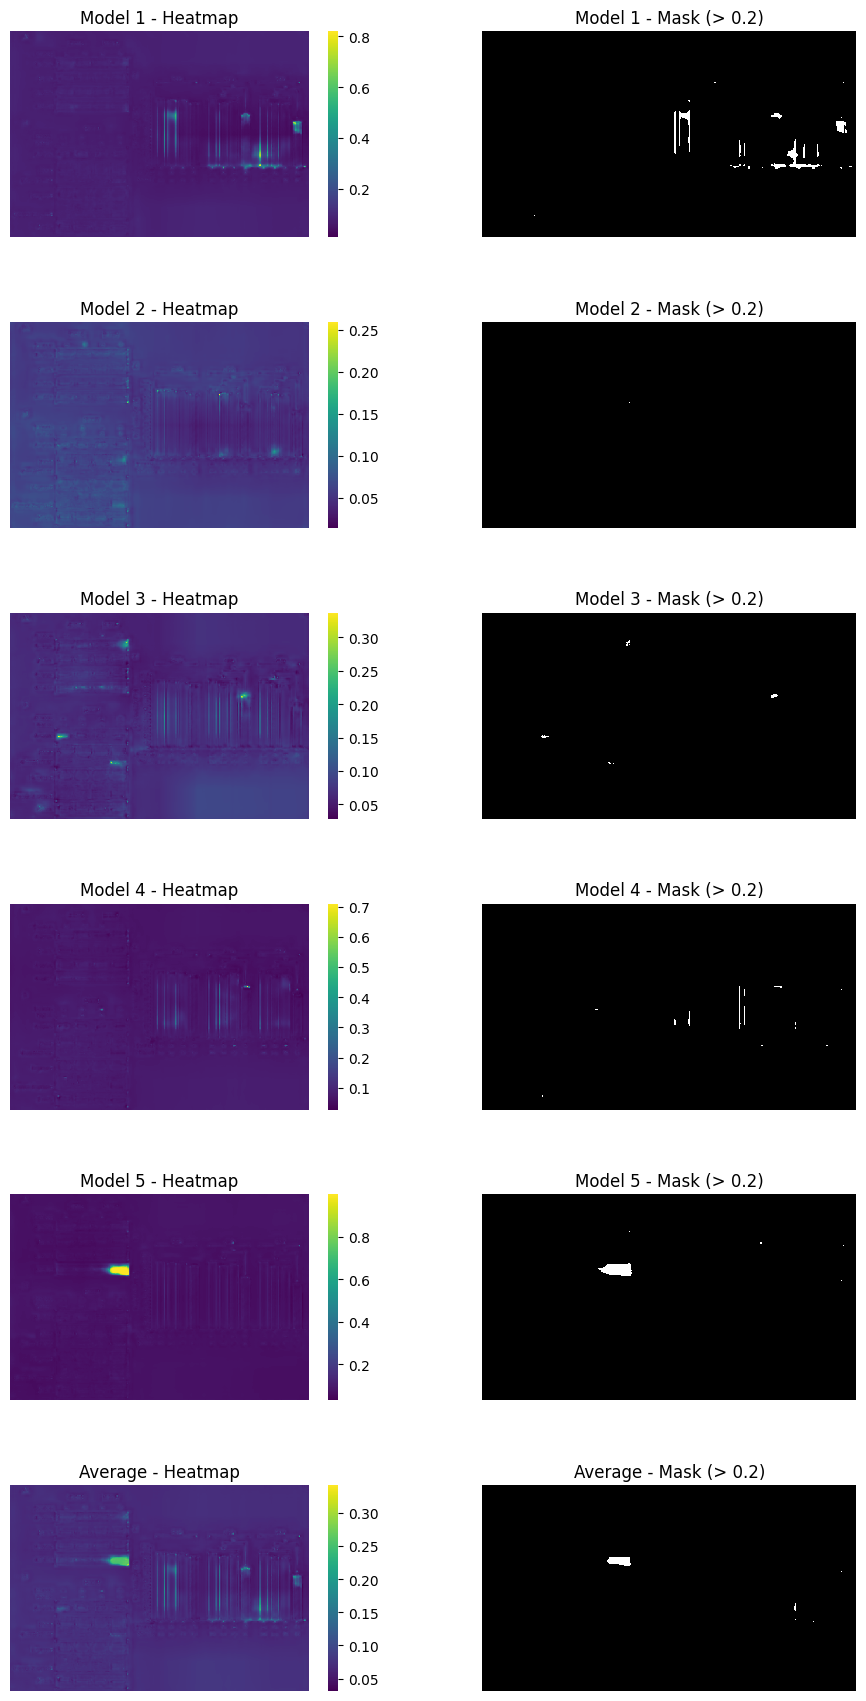


Total time: 145.5s (2.4 min)


,case_id,annotation
0,45,"[969455, 6, 970896, 11, 972338, 15, 973779, 20..."


In [9]:
if __name__ == "__main__":
    import time
    from torchinfo import summary
    set_seed()

    start = time.time()
    print("="*60)
    print("SMP U-Net FORGEY DETECTION")
    print("="*60)

    # Model
    print("\nCreating model...")
    model = MODEL_CLS(**MODEL_CONFIG)

    if isinstance(model, SMPWithSelfCorr):
        model(torch.randn(1, 3, IMG_SIZE, IMG_SIZE)) # 더미 포워드 (Self-Corr 레이어 생성 위해)

    print(model)
    """
    summary(
        model,
        input_size=(1, 3, IMG_SIZE, IMG_SIZE),
        col_names=(
            "input_size",
            "output_size",
            "num_params",
            "mult_adds",
            "kernel_size",
            "trainable"
        ),
        verbose=True
    )
    """

    model = model.to(DEVICE)
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
    print(checkpoint.keys())
    model.load_state_dict(checkpoint, strict=False)
    print("✅ Loaded pretrained weights successfully!")

    params_num = sum(p.numel() for p in model.parameters())
    print(f"Model parameters: {params_num:,} (vs 11M+ for Mask R-CNN)")

    optimizer = optimizer_cls(model.parameters(), lr=LR)

    #Predict
    print("\nPredicting on test set...")
    predictions = predict(
        model=model,
        test_path=paths['test_images'],
        weight_path_list=model_path_list,
        device=DEVICE, 
        img_size=IMG_SIZE,
        interpolation=INTERPOLATION,
        threshold=THRESHOLD,
        min_area_ratio=MIN_AREA_RATIO,
        low_conf_max_prob=LOW_CONF_MAX_PROB,
        low_conf_min_pixel=LOW_CONF_MIN_PIXEL,
        scaler=None,
        train_transform=train_transform,
        test_transform=test_transform
    )

    #Create submission
    sample = pd.read_csv(os.path.join(COMP_DIR, "sample_submission.csv"))
    sample.drop(columns=['annotation'], inplace=True)
    submission = pd.DataFrame(predictions)
    submission = pd.merge(sample, submission, how="left", on='case_id')
    submission.to_csv(os.path.join(OUT_DIR, "submission.csv"), index=False)

    elapsed = time.time() - start
    print(f"\nTotal time: {elapsed:.1f}s ({elapsed/60:.1f} min)")
    display(submission)

# Visualize

Predicting:   0%|          | 0/4 [00:00<?, ?it/s]

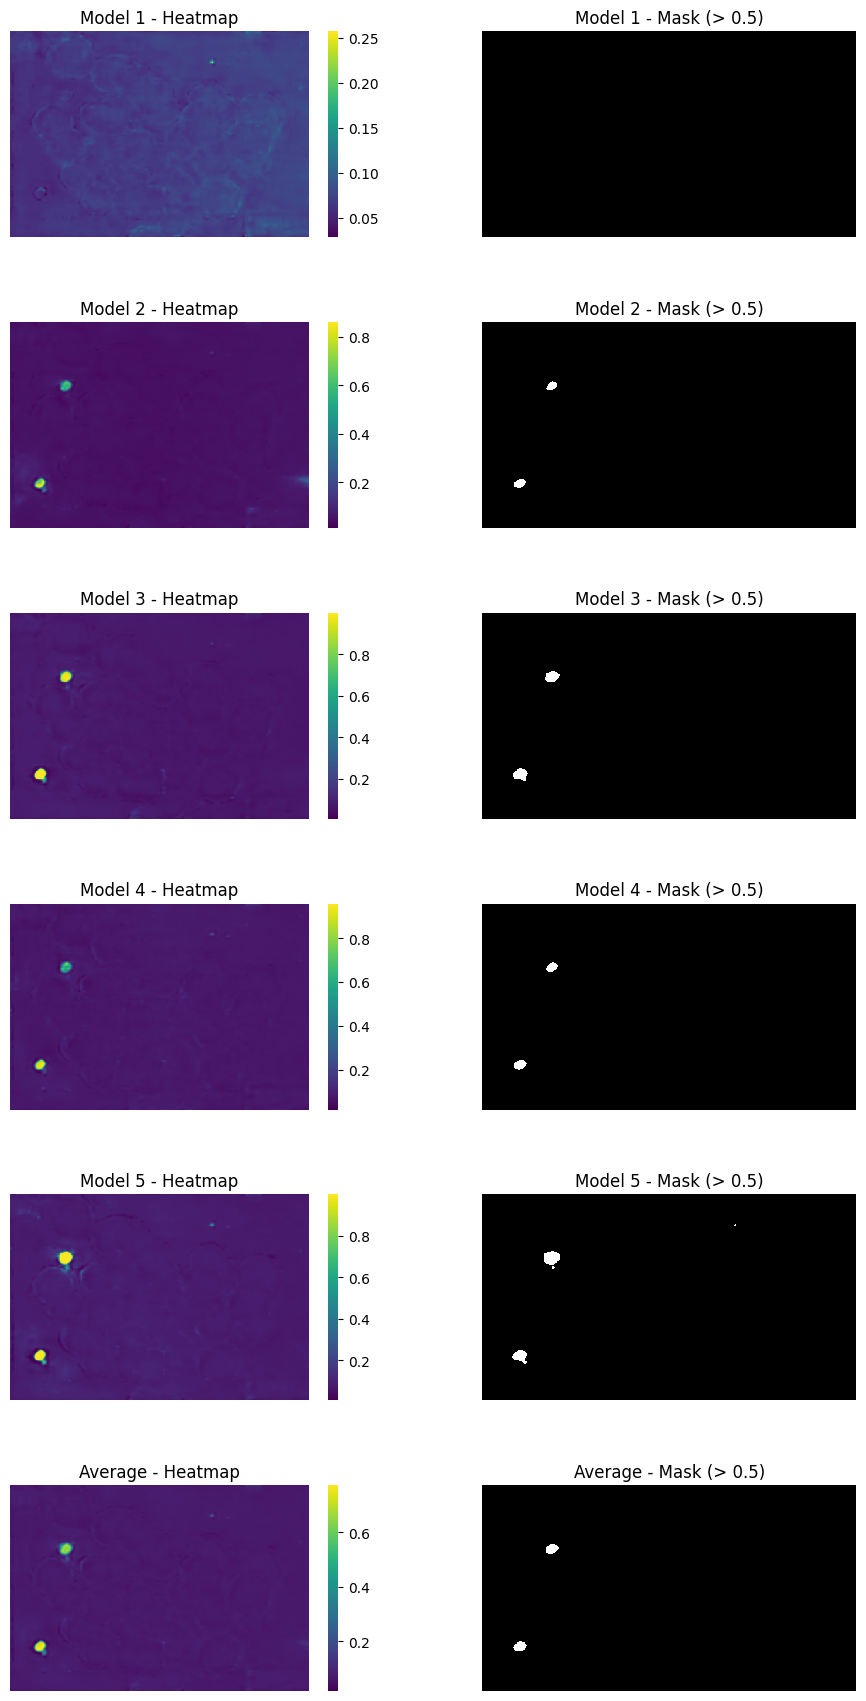

Predicting:  25%|██▌       | 1/4 [00:12<00:36, 12.19s/it]

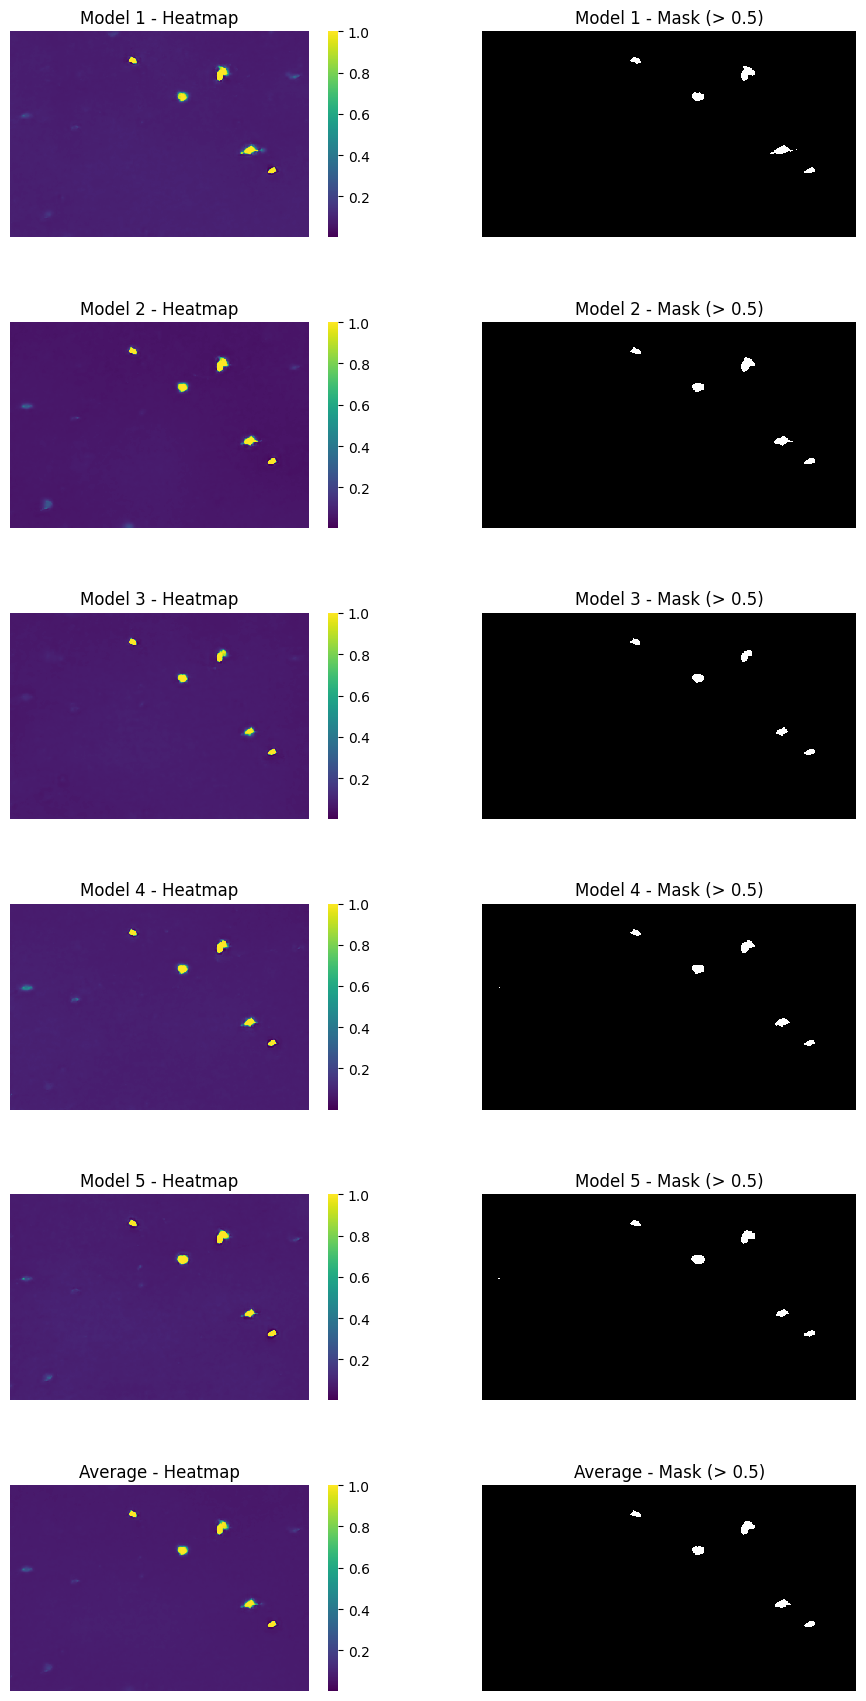

Predicting:  50%|█████     | 2/4 [02:46<03:11, 95.55s/it]

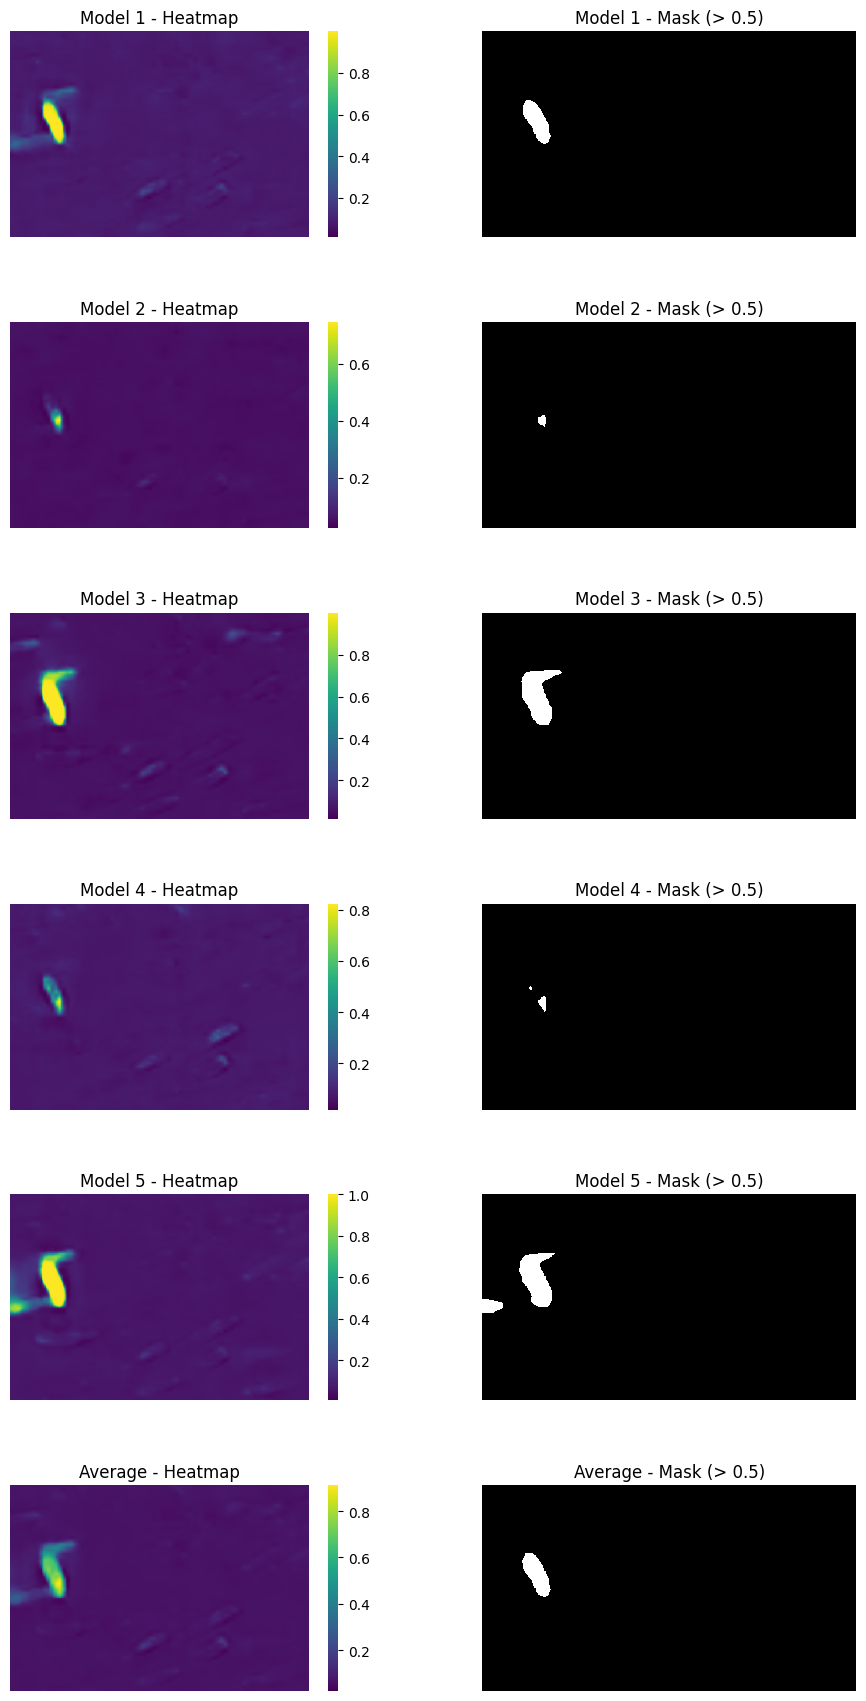

Predicting:  75%|███████▌  | 3/4 [03:02<00:59, 59.32s/it]

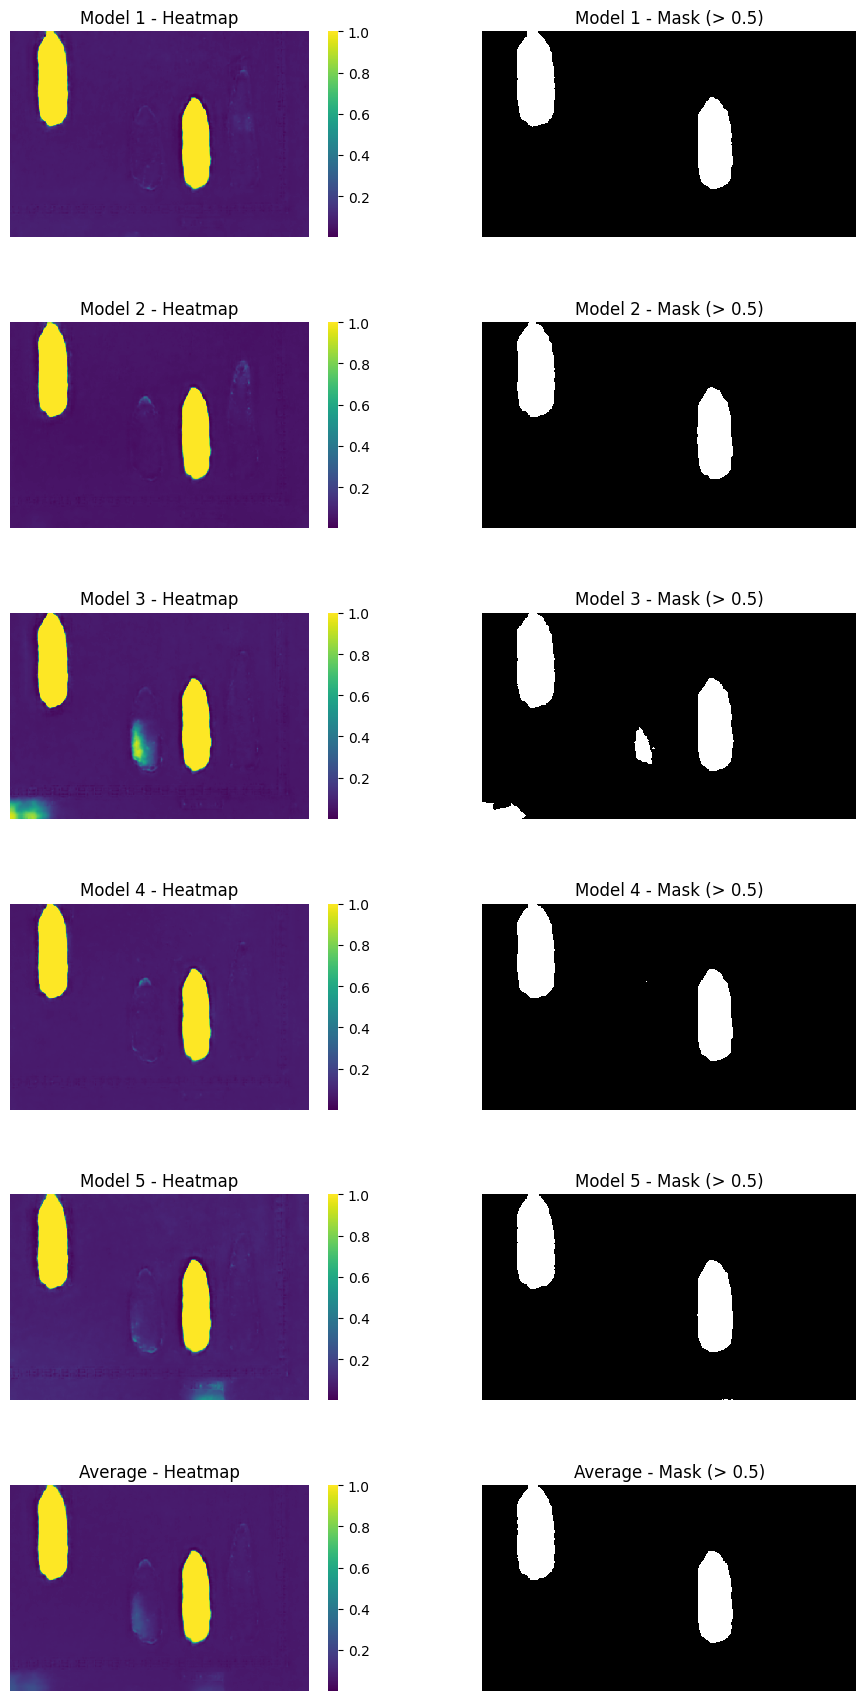

[DEBUG] Original Img size: (512, 648)
[DEBUG] Predictions Counts of semicolun:  0
[DEBUG]  authentic
[DEBUG] Ground Truth RLE Length for case_id 10:  0
[DEBUG] Original Img size: (1200, 1600)
[DEBUG] Predictions Counts of semicolun:  0
[DEBUG]  authentic
[DEBUG] Ground Truth RLE Length for case_id 10015:  0
[DEBUG] Original Img size: (256, 320)
[DEBUG] Predictions Counts of semicolun:  0
[DEBUG]  [9051, 16, 9303, 22, 9557, 25, 9813, 28, 10069, 30, 10325, 31, 10582, 32, 10838, 35, 11094, 40, 11351, 41, 11608, 42, 11866, 44, 12124, 44, 12382, 44, 12640, 43, 12898, 41, 13157, 39, 13417, 35, 13675, 33, 13933, 31, 14192, 27, 14452, 22, 14715, 11]
[DEBUG] Ground Truth RLE Length for case_id 10017:  0
[DEBUG] Original Img size: (666, 1000)
[DEBUG] Predictions Counts of semicolun:  1
[DEBUG]  [62024, 4, 62666, 41, 62722, 5, 62767, 62, 63326, 188, 63989, 194, 64652, 206, 65317, 213, 65981, 220, 66646, 224, 67311, 230, 67974, 237, 68638, 242, 69303, 245, 69966, 249, 70630, 252, 71295, 254, 71960

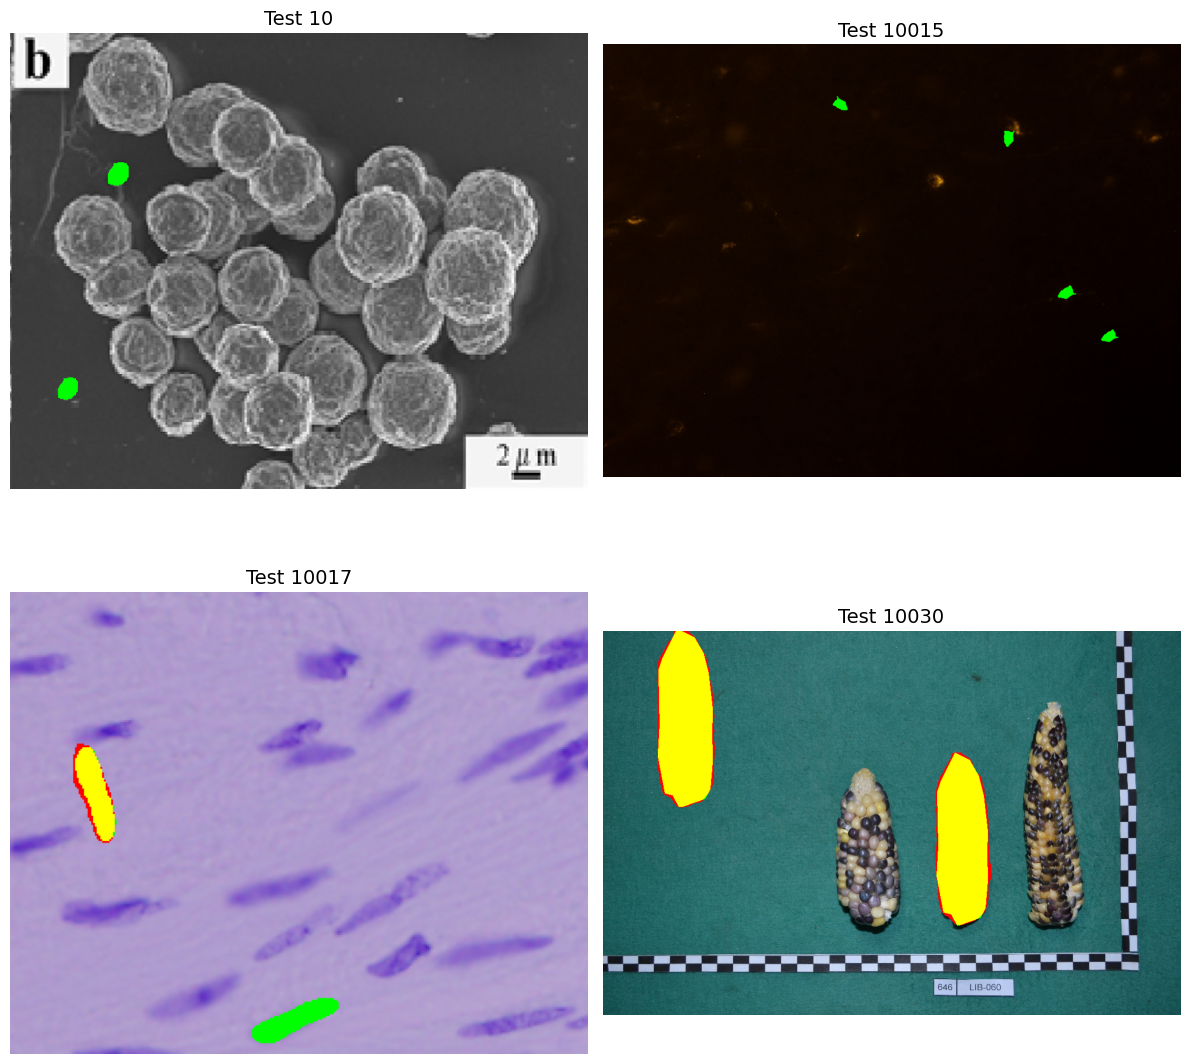

In [10]:
import matplotlib.pyplot as plt

predictions = predict(model, paths['train_forged'], weight_path_list=model_path_list, test_path_file_list=None, device=DEVICE, img_size=IMG_SIZE, max_size=4, train_transform=train_transform, test_transform=test_transform)
sample_ids = predictions['case_id'][:4] 

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for i, case_id in enumerate(sample_ids):
    case_id = str(case_id)
    base_dir = paths['train_forged']

    # 지원할 확장자 목록
    extensions = [".jpg", ".png", ".jpeg"]
    mask_path = os.path.join(paths['train_masks'], f"{case_id}.npy")
    mask_true = np.load(mask_path)
    h, w = mask_true.shape[1:]

    # 존재하는 확장자 찾기
    img_path = None
    for ext in extensions:
        candidate = os.path.join(base_dir, f"{case_id}{ext}")
        if os.path.exists(candidate):
            img_path = candidate
            break
    if img_path is None:
        print(f"Image for case_id {case_id} not found.")
        continue
    
    predictions_df = pd.DataFrame(predictions)
    pred_str = str(predictions_df.loc[predictions_df['case_id']==int(case_id)]['annotation'].values[0])
    
    print(f"[DEBUG] Original Img size: ({h}, {w})")
    print("[DEBUG] Predictions Counts of semicolun: ", pred_str.count(";"))
    print('[DEBUG] ', pred_str)
    mask_rle = rle_encode([mask_true])
    print(f"[DEBUG] Ground Truth RLE Length for case_id {case_id}: ", mask_rle.count(';'))

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # GT (정답 마스크)
    gt_path = os.path.join(paths['train_masks'], f"{case_id}.npy")
    gt = np.load(gt_path)
    if gt.ndim == 3:
        gt = gt.max(axis=0)

    # RLE decode
    if pred_str == "authentic":
        pred_mask = np.zeros_like(gt)
    else:
        masks = [rle_decode(x, shape=gt.shape) for x in pred_str.split(';')]
        pred_mask = np.clip(np.sum(masks, axis=0), 0, 1)

    # 오버레이
    overlay = img_rgb.copy()
    overlay[(gt > 0) & (pred_mask == 0)] = [0, 255, 0]      # 정답만 있는 곳 (초록)
    overlay[(pred_mask > 0) & (gt == 0)] = [255, 0, 0]      # 예측만 있는 곳 (빨강)
    overlay[(pred_mask > 0) & (gt > 0)] = [255, 255, 0]     # 겹치는 곳 (노랑)

    axes[i].imshow(overlay)
    axes[i].set_title(f"Train {case_id}", fontsize=14)
    axes[i].axis("off")

    # 시각화
    axes[i].imshow(overlay)
    axes[i].set_title(f"Test {case_id}", fontsize=14)
    axes[i].axis('off')



plt.tight_layout()
plt.show()

